In [3]:
#A Random Forest regression model was developed to predict boiling points of organic molecules using structural information derived from SMILES representations. 
#The dataset includes over 3,000 molecules with diverse atomic compositions and functional groups.

import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# load dataset
df = pd.read_csv("bp_data.csv")


# function to convert SMILES → Morgan fingerprint
def morgan_fp(smiles, radius=2, nBits=2048):
    
    mol = Chem.MolFromSmiles(smiles)
    
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=radius,
        nBits=nBits
    )
    
    arr = np.zeros((nBits,))
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

In [5]:
fingerprints = []

for s in df["SMILES"]:
    arr = morgan_fp(s)
    fingerprints.append(arr)

X = np.array(fingerprints)

In [ ]:
from sklearn.feature_selection import VarianceThreshold
before_shape = X.shape

selector = VarianceThreshold(threshold=0.0)
X = selector.fit_transform(X)

after_shape = X.shape

print("before:", before_shape)
print("after:", after_shape)

In [7]:
# target variable
y = df["bp_K"]


# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# train Random Forest
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


# predictions
y_pred = model.predict(X_test)


# evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 42.72796841596355
RMSE: 62.87427168551172
R2: 0.6093947088885243


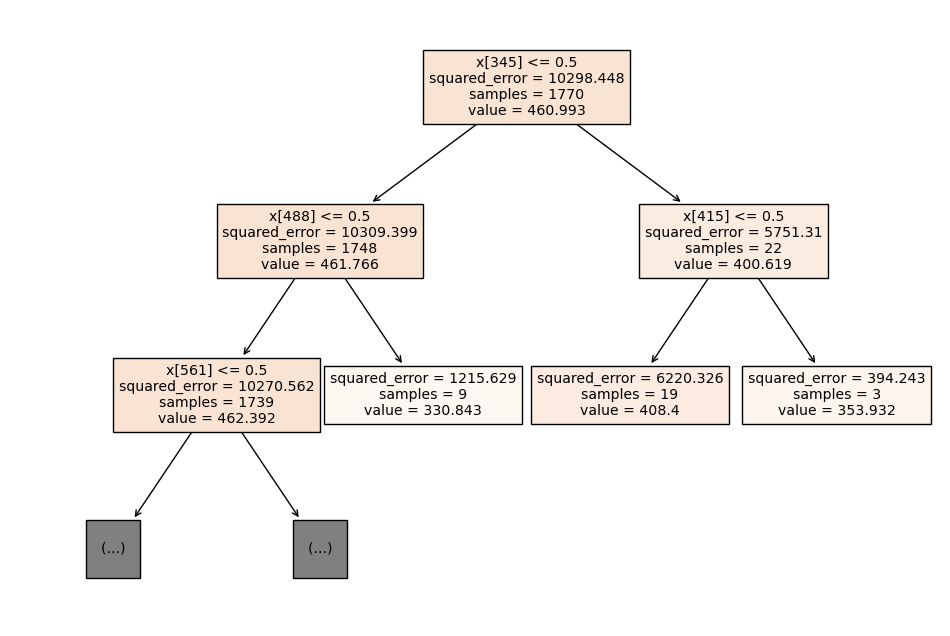

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = model.estimators_[0]

plt.figure(figsize=(12,8))

plot_tree(
    tree,
    filled=True,
    max_depth=2
)

plt.show()

In [11]:
import pandas as pd

importance = pd.Series(model.feature_importances_)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

349    0.104777
438    0.060125
570    0.047728
166    0.042404
389    0.032525
417    0.022581
216    0.022467
231    0.022235
209    0.020360
525    0.019510
dtype: float64


In [12]:
from sklearn.ensemble import GradientBoostingRegressor
# create model
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


# train model
model.fit(X_train, y_train)


# predictions
y_pred = model.predict(X_test)


# evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 48.628400891853616
RMSE: 65.86924253775565
R2: 0.5712960097764385


In [16]:
import numpy as np

importances = model.feature_importances_

In [17]:
indices = np.argsort(importances)[::-1]

top_features = indices[:20]

print(top_features)

[1143 1380 1911  146  755  222 1750  739   55  807  657  201  903   80
 1366  110 1992 1908   25 1057]


In [18]:
print("Top 10 importance values:")
print(importances[indices[:10]])

Top 10 importance values:
[0.2952101  0.07613126 0.05218414 0.04883805 0.04068965 0.02880336
 0.02404416 0.02257059 0.02185454 0.02116887]


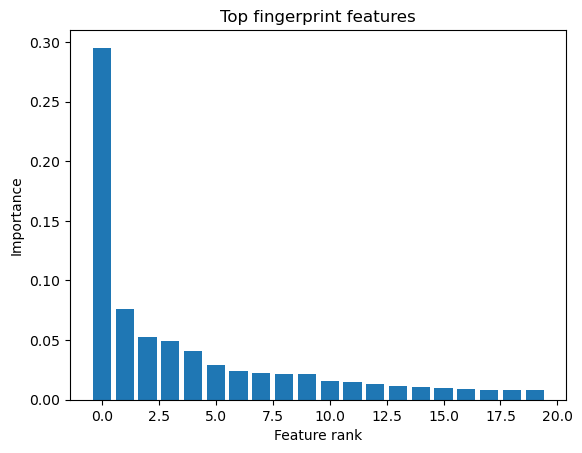

In [19]:
import matplotlib.pyplot as plt

plt.bar(range(20), importances[indices[:20]])
plt.xlabel("Feature rank")
plt.ylabel("Importance")
plt.title("Top fingerprint features")
plt.show()

In [20]:
from rdkit import Chem
from rdkit.Chem import AllChem

mol = Chem.MolFromSmiles(df["SMILES"][0])

bitInfo = {}

fp = AllChem.GetMorganFingerprintAsBitVect(
    mol,
    radius=2,
    nBits=2048,
    bitInfo=bitInfo
)

In [21]:
bitInfo

{67: ((5, 2),),
 89: ((1, 1),),
 160: ((3, 2),),
 598: ((4, 1),),
 807: ((1, 0),),
 835: ((8, 2),),
 872: ((6, 2),),
 926: ((4, 0), (8, 0), (9, 0)),
 974: ((3, 1),),
 1017: ((2, 1),),
 1019: ((3, 0),),
 1022: ((0, 1),),
 1057: ((2, 0), (7, 0)),
 1325: ((9, 1),),
 1366: ((0, 0),),
 1380: ((6, 0),),
 1579: ((4, 2),),
 1722: ((7, 1),),
 1738: ((8, 1),),
 1781: ((5, 1),),
 1784: ((9, 2),),
 1873: ((5, 0),),
 1979: ((6, 1),),
 2044: ((1, 2),)}

In [22]:
important_bit = indices[0]
print(important_bit)

1143


In [26]:
if important_bit in bitInfo:
    print(bitInfo[important_bit])

In [27]:
importances = model.feature_importances_

In [28]:
import numpy as np

bit_frequency = np.sum(X, axis=0)

In [29]:
import numpy as np

bit_frequency = np.sum(X, axis=0)

In [30]:
print(bit_frequency)

[   8. 1223.   40. ...   10.   18.    5.]


In [30]:
print(bit_frequency)

[   8. 1223.   40. ...   10.   18.    5.]


In [31]:
target_bit = 1

for smiles in df["SMILES"]:
    
    mol = Chem.MolFromSmiles(smiles)
    bitInfo = {}

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=2048,
        bitInfo=bitInfo
    )

    if target_bit in bitInfo:
        print("SMILES:", smiles)
        print("bitInfo:", bitInfo[target_bit])
        break

SMILES: ClC(Cl)c1ccccc1
bitInfo: ((1, 0),)


In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ---- remove rare fingerprint bits ----
bit_frequency = X.sum(axis=0)

mask = bit_frequency > 10
X_filtered = X[:, mask]


# ---- train test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y,
    test_size=0.2,
    random_state=42
)


# ---- Random Forest model ----
model = RandomForestRegressor(
    n_estimators=1000,
    max_features="sqrt",
    max_depth=25,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)


# ---- training ----
model.fit(X_train, y_train)


# ---- prediction ----
y_pred = model.predict(X_test)


# ---- evaluation ----
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 48.78593927641752
RMSE: 67.76914378330093
R2: 0.5462086800676833
